
N = 8
a = 3

Since gcd(3,8) = 1, 3 belongs to the multiplicative modulo group modulo 8.
We will find the order r such that 3^r ≡ 1 mod 8.

Smallest n such that 2^n >= N is n = 3
Because 2^3 = 8 >= 8

Number of upper/counting qubits m = 2n + 1 = 7

Created circuit with total qubits = m+n = 10
Upper/counting register: q[0] to q[6]
Lower/work register: q[7] to q[9]

Lower register initialized to |1>.

The basic modular multiplication unitary U_a is:

[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]]

Verification successful: U_a is unitary.

Hadamard gates applied on the u

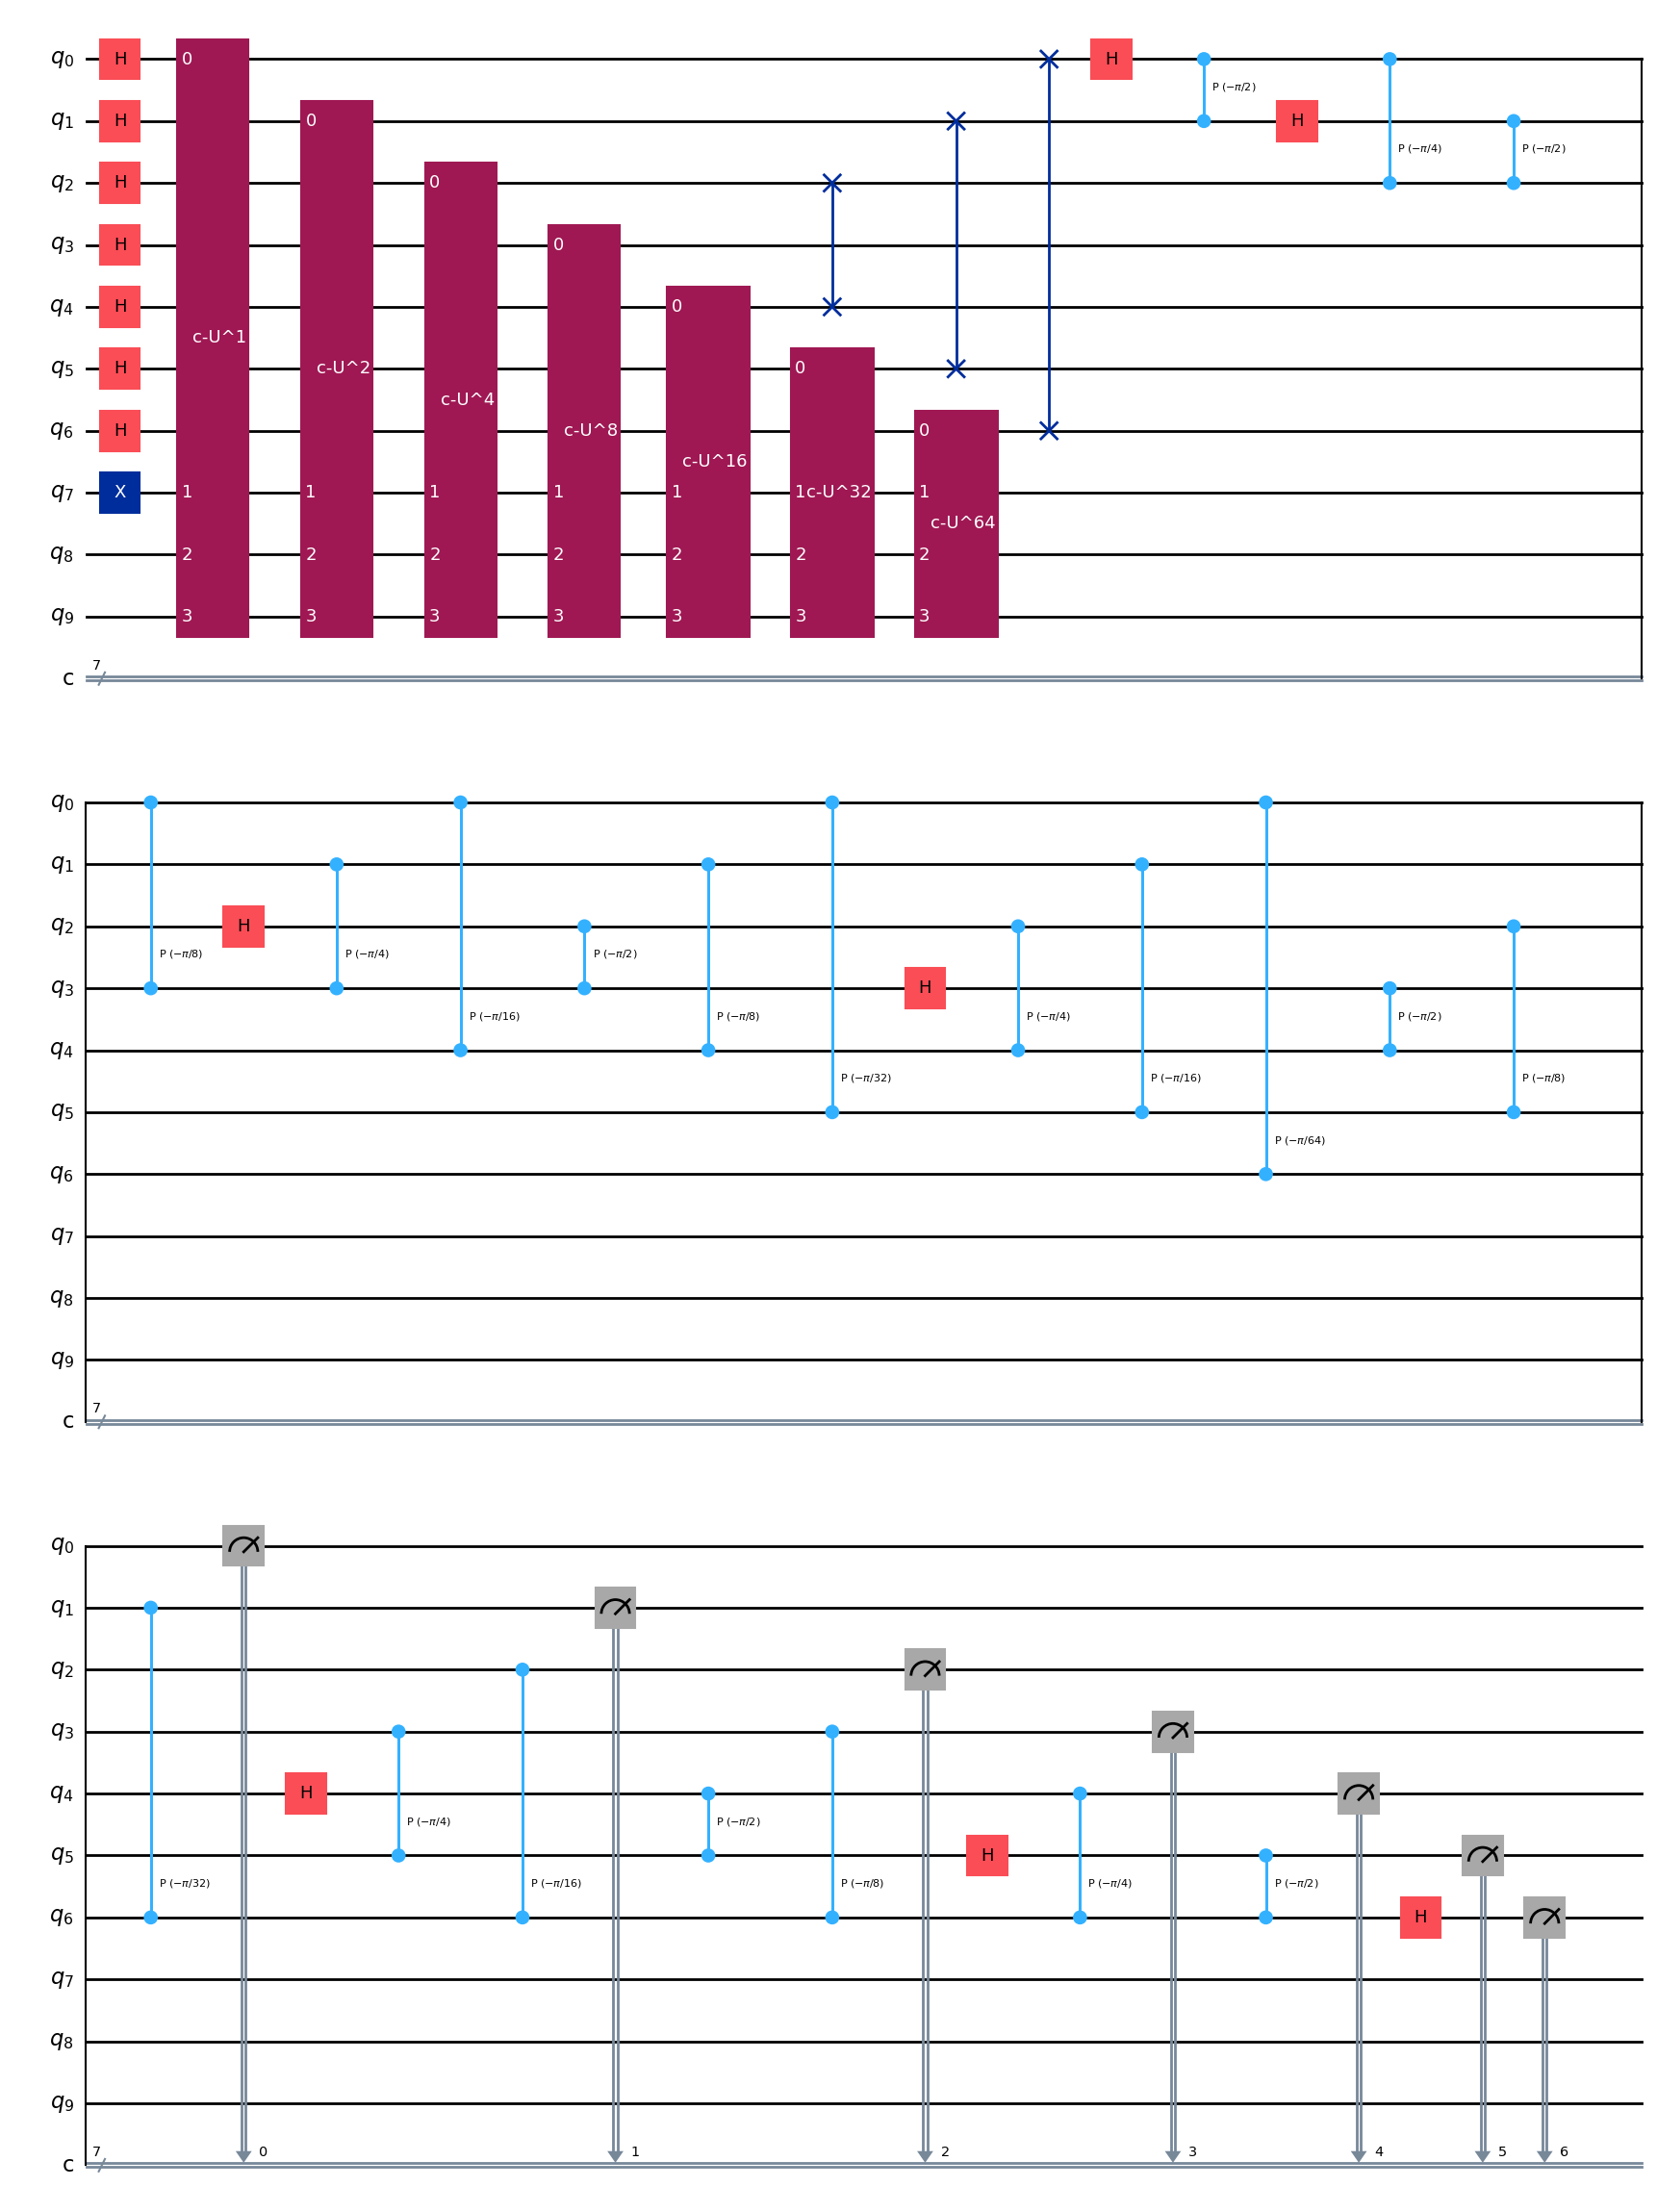


Measurement counts:
{'1000000': 1025, '0000000': 1023}


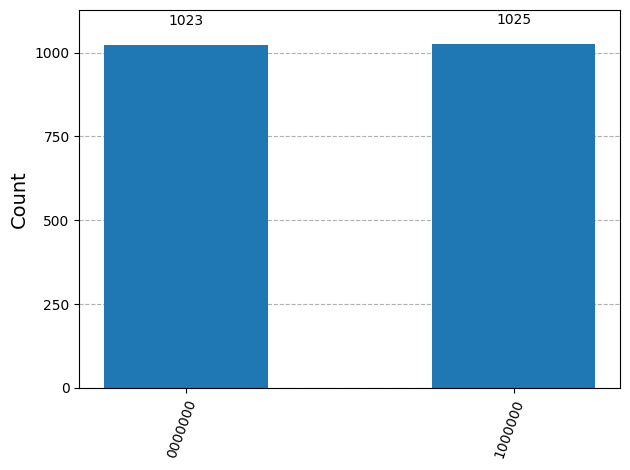


Trying measured output: 1000000
Count: 1025

--------------------------------
Measured bitstring = 1000000
Measured integer t = 64
Measured phase ≈ 64/128 = 0.5
Continued fraction gives approximately: 1/2
Candidate order from denominator: r = 2
Success: 3^2 mod 8 = 1

################################
Final order found: r = 2
Verification: 3^2 mod 8 = 1
################################


In [ ]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import *
from qiskit.visualization import plot_histogram
from numpy import sqrt
from IPython.display import Math, display
from qiskit.circuit.library import UnitaryGate
from numpy import pi, cos, sin, exp
from qiskit_aer import AerSimulator
from qiskit_aer.library import save_statevector
import random
import numpy as np
import math
from fractions import Fraction

# User input

N = int(input("Enter N: "))
a = int(input("Enter a whose order modulo N is to be found: "))

print("\nN =", N)
print("a =", a)

if N <= 1:
    raise ValueError("N must be greater than 1.")

if math.gcd(a, N) != 1:
    raise ValueError(
        f"Error: a = {a} does not belong to the multiplicative modulo group of {N}, "
        f"because gcd({a},{N}) = {math.gcd(a,N)} ≠ 1"
    )

print(f"\nSince gcd({a},{N}) = 1, {a} belongs to the multiplicative modulo group modulo {N}.")
print(f"We will find the order r such that {a}^r ≡ 1 mod {N}.")

# Choose smallest n such that 2^n >= N

n = 0
while 2**n < N:
    n += 1

print(f"\nSmallest n such that 2^n >= N is n = {n}")
print(f"Because 2^{n} = {2**n} >= {N}")

# Upper register size

m = 2*n + 1

print(f"\nNumber of upper/counting qubits m = 2n + 1 = {m}")

# Create quantum circuit

q = QuantumRegister(m + n, "q")
c = ClassicalRegister(m, "c")

qc = QuantumCircuit(q, c)

print(f"\nCreated circuit with total qubits = m+n = {m+n}")
print(f"Upper/counting register: q[0] to q[{m-1}]")
print(f"Lower/work register: q[{m}] to q[{m+n-1}]")

# Initialize lower n-bit register to |1>

# In Qiskit little-endian convention, q[m] is the least significant qubit
# of the lower register. So applying X to q[m] initializes lower register to |1>.
qc.x(q[m])

print("\nLower register initialized to |1>.")

# Modular multiplication unitary U_a

def modular_multiplication_unitary(a, N, n):
    """
    Creates the n-qubit unitary U_a:

        U_a |x> = |a*x mod N>,   if 0 <= x < N
        U_a |x> = |x>,           if N <= x < 2^n

    Matrix convention:
        U[output_state, input_state] = 1
    """

    dim = 2**n
    U = np.zeros((dim, dim), dtype=complex)

    for x in range(dim):

        if x < N:
            y = (a * x) % N
        else:
            y = x

        U[y, x] = 1

    return U


U_a = modular_multiplication_unitary(a, N, n)

np.set_printoptions(linewidth=200, suppress=True)

print("\nThe basic modular multiplication unitary U_a is:\n")
print(U_a)

if np.allclose(U_a.conj().T @ U_a, np.eye(2**n)):
    print("\nVerification successful: U_a is unitary.")
else:
    raise ValueError("Something is wrong: U_a is not unitary.")

# Apply Hadamard to upper m qubits

for i in range(m):
    qc.h(q[i])

print(f"\nHadamard gates applied on the upper {m} counting qubits.")

# Controlled modular multiplication WITHOUT .control()

def controlled_modular_multiplication_unitary(a_power, N, n):
    """
    Directly creates the controlled modular multiplication unitary.

    Control qubit + n target qubits.

    If control = 0:
        |0>|x> -> |0>|x>

    If control = 1:
        |1>|x> -> |1>|a_power*x mod N>, if x < N
        |1>|x> -> |1>|x>,               if x >= N

    Qiskit little-endian convention for local qubits:
        local basis index = control_bit + 2*x
    """

    target_dim = 2**n
    total_dim = 2 * target_dim

    CU = np.zeros((total_dim, total_dim), dtype=complex)

    for x in range(target_dim):

        # control = 0
        input_index_0 = 2*x
        output_index_0 = 2*x
        CU[output_index_0, input_index_0] = 1

        # control = 1
        if x < N:
            y = (a_power * x) % N
        else:
            y = x

        input_index_1 = 2*x + 1
        output_index_1 = 2*y + 1
        CU[output_index_1, input_index_1] = 1

    return CU


for i in range(m):

    power = 2**i

    # U_a^(2^i) = U_{a^(2^i) mod N}
    a_power = pow(a, power, N)

    CU_power = controlled_modular_multiplication_unitary(a_power, N, n)

    if not np.allclose(CU_power.conj().T @ CU_power, np.eye(2**(n+1))):
        raise ValueError(f"Controlled-U^{power} is not unitary.")

    CU_power_gate = UnitaryGate(CU_power, label=f"c-U^{power}")

    # Apply on:
    # control qubit = q[i]
    # target qubits = q[m], q[m+1], ..., q[m+n-1]
    qc.append(
        CU_power_gate,
        [q[i]] + [q[m + j] for j in range(n)]
    )

print("\nControlled modular multiplication gates applied without using .control().")

# Inverse QFT on upper m qubits

def apply_inverse_qft(qc, q_reg, m):
    """
    Applies inverse QFT on q_reg[0], q_reg[1], ..., q_reg[m-1].
    This follows your earlier inverse QFT structure.
    """

    # First SWAP part
    for i in range(m // 2):
        qc.swap(q_reg[i], q_reg[m - i - 1])

    # Inverse QFT main part
    for i in range(m):
        p = i

        for j in range(p):
            qc.cp(
                -2*pi/(2**(p - j + 1)),
                q_reg[j],
                q_reg[p]
            )

        qc.h(q_reg[p])


apply_inverse_qft(qc, q, m)

print(f"\nInverse QFT applied on the upper {m} qubits.")

# Measure upper m qubits

for i in range(m):
    qc.measure(q[i], c[i])

print(f"\nMeasured the upper {m} counting qubits.")

display(qc.draw(output="mpl", style="iqp"))

# Simulation

shots = 2048

simulator = AerSimulator()

result = simulator.run(qc, shots=shots).result()
counts = result.get_counts()

print("\nMeasurement counts:")
print(counts)

display(plot_histogram(counts))

# Continued fraction post-processing

def get_order_from_measurement(bitstring, a, N, m):
    """
    From measured bitstring, recover candidate order r.

    Measurement gives integer t such that:

        t / 2^m ≈ j / r

    where r is the order of a modulo N.
    """

    t = int(bitstring, 2)

    print("\n--------------------------------")
    print("Measured bitstring =", bitstring)
    print("Measured integer t =", t)

    if t == 0:
        print("t = 0 gives phase 0, so order cannot be extracted from this result.")
        return None

    phase = t / (2**m)

    print(f"Measured phase ≈ {t}/{2**m} = {phase}")

    frac = Fraction(t, 2**m).limit_denominator(N)

    j_candidate = frac.numerator
    r_candidate = frac.denominator

    print(f"Continued fraction gives approximately: {j_candidate}/{r_candidate}")
    print(f"Candidate order from denominator: r = {r_candidate}")

    if pow(a, r_candidate, N) == 1:
        print(f"Success: {a}^{r_candidate} mod {N} = 1")
        return r_candidate

    print(f"But {a}^{r_candidate} mod {N} = {pow(a, r_candidate, N)}, not 1.")

    print("Checking multiples of candidate denominator...")

    for k in range(2, N + 1):

        possible_r = k * r_candidate

        if possible_r > N:
            break

        if pow(a, possible_r, N) == 1:
            print(f"Success: {a}^{possible_r} mod {N} = 1")
            print(f"Actual order found: r = {possible_r}")
            return possible_r

    print("Failed to extract order from this measurement.")
    return None

# Try measurement results from highest count

sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)

r_found = None

for bitstring, count in sorted_counts:

    print("\n================================")
    print(f"Trying measured output: {bitstring}")
    print(f"Count: {count}")
    print("================================")

    r_candidate = get_order_from_measurement(bitstring, a, N, m)

    if r_candidate is not None:
        r_found = r_candidate
        break

# Final answer

if r_found is not None:
    print("\n################################")
    print(f"Final order found: r = {r_found}")
    print(f"Verification: {a}^{r_found} mod {N} = {pow(a, r_found, N)}")
    print("################################")
else:
    print("\nNo valid order found from this run.")
    print("Try running the circuit again.")